In [26]:
import ast
import os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from mpl_toolkits.mplot3d.art3d import Line3DCollection

BLUE_RED = LinearSegmentedColormap.from_list("blue_red", ["#0d2be0", "#d40000"])


def plot_entries(entries, title=None, connect=False, ax=None,
                 save=None, dpi=150, close=False,
                 stems=False, stem_base=None, cmap=BLUE_RED,
                 vmin=None, vmax=None, colorbar=True, s=2,
                 elev_value=30, azim_value=-30, label_size=25):
    """3D plot: x = k, y = p, z = data value.
    Points and stems are colored by z, dark (low) to light (high).
    stems      -- draw a vertical segment from stem_base up to each point
    stem_base  -- z of the stem feet; None = global minimum (0.0 is often better)
    cmap       -- colormap or name;
    vmin/vmax  -- fix the color scale
    s          -- marker area for the scatter points
    elev_value -- elevation value for plot  # matplotlib's default is elev=30
    azim_value -- azimuthal angle for plot (spin around the z-axis) # matplotlib's default is azim=-60
    label_size -- font size of the axis labels (tick numbering is unaffected)
    save       -- path to write the figure to (e.g. "l3.png"); None to skip
    close      -- close the figure after saving, to avoid piling up memory
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(projection="3d")
    else:
        fig = ax.get_figure()

    cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    ax.view_init(elev=elev_value, azim=-azim_value)

    all_z = np.concatenate([np.asarray(e[4], dtype=float) for e in entries])
    lo = all_z.min() if vmin is None else vmin
    hi = all_z.max() if vmax is None else vmax
    if lo == hi:                      # degenerate scale
        lo, hi = lo - 0.5, hi + 0.5
    norm = Normalize(vmin=lo, vmax=hi)

    if stem_base is None:
        stem_base = float(all_z.min())

    for p, l, k_min, k_max, data in entries:
        zs = np.asarray(data, dtype=float)
        ks = np.arange(k_min, k_min + len(zs))       # x
        pcol = np.full(len(ks), float(p))            # y
        cs = cmap(norm(zs))

        if stems:
            segs = [((k, y, stem_base), (k, y, z))
                    for k, y, z in zip(ks, pcol, zs)]
            ax.add_collection3d(
                Line3DCollection(segs, colors=cs, lw=0.6, alpha=0.5))

        if connect and len(zs) > 1:
            pts = np.column_stack([ks, pcol, zs])
            segs = np.stack([pts[:-1], pts[1:]], axis=1)
            mids = cmap(norm(0.5 * (zs[:-1] + zs[1:])))
            ax.add_collection3d(
                Line3DCollection(segs, colors=mids, lw=1.0, alpha=0.85))

        ax.scatter(ks, pcol, zs, c=cs, s=s, depthshade=False)

    # collections don't feed the autoscaler, so pin z by hand
    zlo = min(all_z.min(), stem_base)
    zhi = max(all_z.max(), stem_base)
    pad = 0.05 * (zhi - zlo) or 1.0
    ax.set_zlim(zlo - pad, zhi + pad)

    ax.set_xlabel("k", fontsize=label_size, labelpad=12)
    ax.set_ylabel("p", fontsize=label_size, labelpad=12)
    ax.set_zlabel("value", fontsize=label_size, labelpad=12)
    if title:
        ax.set_title(title)

    if colorbar:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.10)
        cb.set_label("value", size=label_size)

    if save is not None:
        fig.savefig(save, dpi=dpi, bbox_inches="tight")
        if close:
            plt.close(fig)

    return ax


def parse_max_battery(source):
    """
    Parse output of Magma's sweep_max_bound_battery.
    Each line: (p, l, k, N, max_err, violations)

    source -- a file path, a list of file paths, or a string of raw text.
    Returns a list of tuples (p, l, k, N, eps, violations).
    """
    if isinstance(source, (list, tuple)):
        return [r for s in source for r in parse_max_battery(s)]
    text = open(source).read() if os.path.exists(source) else source

    rows = []
    for line in text.splitlines():
        line = line.strip()
        if not line.startswith("("):
            continue
        t = ast.literal_eval(line)
        if len(t) != 6:
            raise ValueError(f"expected 6 fields (p,l,k,N,max_err,violations), got: {line}")
        p, l, k, N, eps, viol = t
        rows.append((int(p), int(l), int(k), int(N), float(eps), int(viol)))
    return rows


def max_battery_to_entries(rows, N=None, l=None, z_range=None):
    """
    Convert parsed rows to the (p, l, k_min, k_max, data) entries used by
    plot_entries. Selects one class N and one prime l (inferred if unique).

    Duplicate (p, k) pairs are merged by taking the max eps FIRST; then, if
    z_range = (lo, hi) is given, any (p, k) whose merged eps lies outside
    [lo, hi] is removed. Gaps in k become separate entries.

    Returns (entries, dropped, N, l), with dropped a list of (p, k, eps).
    """
    Ns = sorted({r[3] for r in rows})
    ls = sorted({r[1] for r in rows})
    if N is None:
        if len(Ns) != 1:
            raise ValueError(f"several classes present {Ns}; pass N=")
        N = Ns[0]
    if l is None:
        if len(ls) != 1:
            raise ValueError(f"several l present {ls}; pass l=")
        l = ls[0]

    by_p = defaultdict(dict)
    for p, ll, k, NN, eps, _ in rows:
        if NN == N and ll == l:
            by_p[p][k] = max(eps, by_p[p].get(k, float("-inf")))
    if not by_p:
        raise ValueError(f"no rows with N={N}, l={l}")

    dropped = []
    if z_range is not None:
        lo, hi = z_range
        for p in list(by_p):
            for k, eps in list(by_p[p].items()):
                if not (lo <= eps <= hi):
                    dropped.append((p, k, eps))
                    del by_p[p][k]
            if not by_p[p]:
                del by_p[p]

    entries = []
    for p in sorted(by_p):
        ks = sorted(by_p[p])
        start = prev = ks[0]
        run = [by_p[p][start]]
        for k in ks[1:]:
            if k == prev + 1:
                run.append(by_p[p][k])
            else:
                entries.append((p, l, start, prev, run))
                start, run = k, [by_p[p][k]]
            prev = k
        entries.append((p, l, start, prev, run))
    return entries, dropped, N, l


def plot_max_bound(source, N=None, l=None, z_range=(0.0, 1.0),
                   show_bound=False, title=None, **kwargs):
    """
    Plot output of the max-value battery: x = k, y = p, z = max eps.

    source     -- file path(s) or raw text from sweep_max_bound_battery
    N, l       -- class label (1..5) and prime; inferred if only one is present
    z_range    -- only plot points with lo <= eps <= hi; None plots everything
    show_bound -- draw a translucent plane at eps = 1
    **kwargs   -- passed to plot_entries (save=, connect=, cmap=, s=, ...)

    Defaults: stems on, stem base 0, color scale fixed to z_range, so
    figures for different classes share one scale.
    """
    rows = parse_max_battery(source)
    entries, dropped, N_used, l_used = max_battery_to_entries(
        rows, N=N, l=l, z_range=z_range)

    n_kept = sum(len(e[4]) for e in entries)
    if dropped:
        worst = max(dropped, key=lambda t: t[2])
        print(f"dropped {len(dropped)} of {n_kept + len(dropped)} points outside "
              f"{list(z_range)}; worst: p={worst[0]}, k={worst[1]}, eps={worst[2]:.4f}")
    if not entries:
        raise ValueError("no points left in z_range")

    kwargs.setdefault("stems", False)
    kwargs.setdefault("stem_base", 0.0)
    if z_range is not None:
        kwargs.setdefault("vmin", z_range[0])
        kwargs.setdefault("vmax", z_range[1])
    else:
        kwargs.setdefault("vmin", 0.0)
    # plot_entries saves inside itself, so defer saving until the overlay is drawn
    save = kwargs.pop("save", None)
    close = kwargs.pop("close", False)
    dpi = kwargs.get("dpi", 150)
    ax = plot_entries(entries, title=title, **kwargs)

    ks = np.array([k for _, _, k0, _, d in entries for k in range(k0, k0 + len(d))])
    ps = np.array([p for p, _, _, _, d in entries for _ in d])
    zs = np.concatenate([np.asarray(d, dtype=float) for *_, d in entries])
    print(f"plotted {len(zs)} points, max eps = {zs.max():.4f}")

    if show_bound:
        K, P = np.meshgrid([ks.min(), ks.max()], [ps.min(), ps.max()])
        ax.plot_surface(K, P, np.ones_like(K, dtype=float),
                        color="gray", alpha=0.2, linewidth=0)
        ax.set_zlim(ax.get_zlim()[0], max(ax.get_zlim()[1], 1.05))

    if save is not None:
        ax.get_figure().savefig(save, dpi=dpi, bbox_inches="tight")
        if close:
            plt.close(ax.get_figure())
    return ax


maximal_l_eq_2_filename = "max_bound_l2_maximal.dat"
submaximal_index_p_l_eq_2_filename = "max_bound_l2_index_p.dat"
submaximal_index_q_l_eq_2_filename = "max_bound_l2_index_q.dat"
submaximal_index_q2_l_eq_2_filename = "max_bound_l2_index_q2.dat"
submaximal_index_p2_l_eq_2_filename = "max_bound_l2_index_p2.dat"

dropped 6 of 76950 points outside [0.0, 1.0]; worst: p=17, k=15, eps=4.5254
plotted 76944 points, max eps = 0.9283


<Axes3DSubplot: xlabel='k', ylabel='p', zlabel='value'>

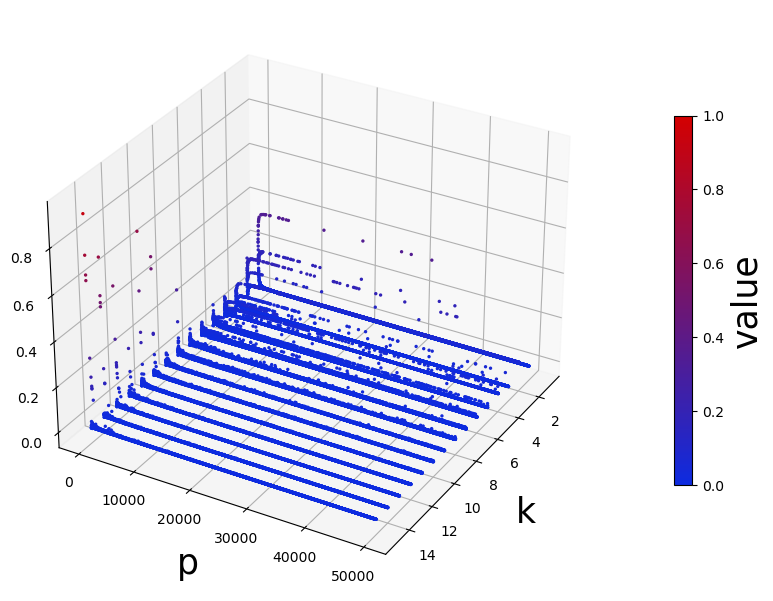

In [28]:
plot_max_bound(maximal_l_eq_2_filename, save="maximal-max_error_l-2.pdf")

plotted 76950 points, max eps = 0.1582


<Axes3DSubplot: xlabel='k', ylabel='p', zlabel='value'>

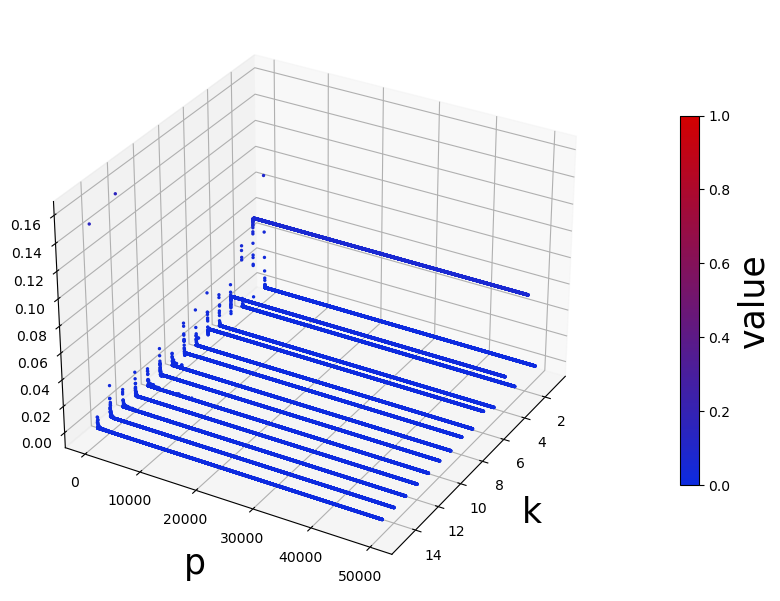

In [29]:
plot_max_bound(submaximal_index_p_l_eq_2_filename, save="submaximal_index_p-max_error_l-2.pdf")

plotted 76950 points, max eps = 0.6704


<Axes3DSubplot: xlabel='k', ylabel='p', zlabel='value'>

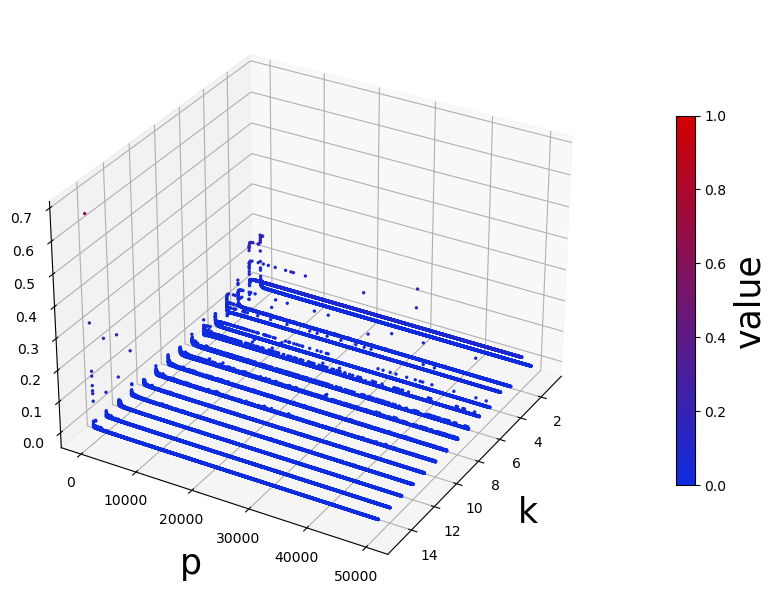

In [30]:
plot_max_bound(submaximal_index_q_l_eq_2_filename, save="submaximal_index_q-max_error_l-2.pdf")

plotted 76950 points, max eps = 0.1832


<Axes3DSubplot: xlabel='k', ylabel='p', zlabel='value'>

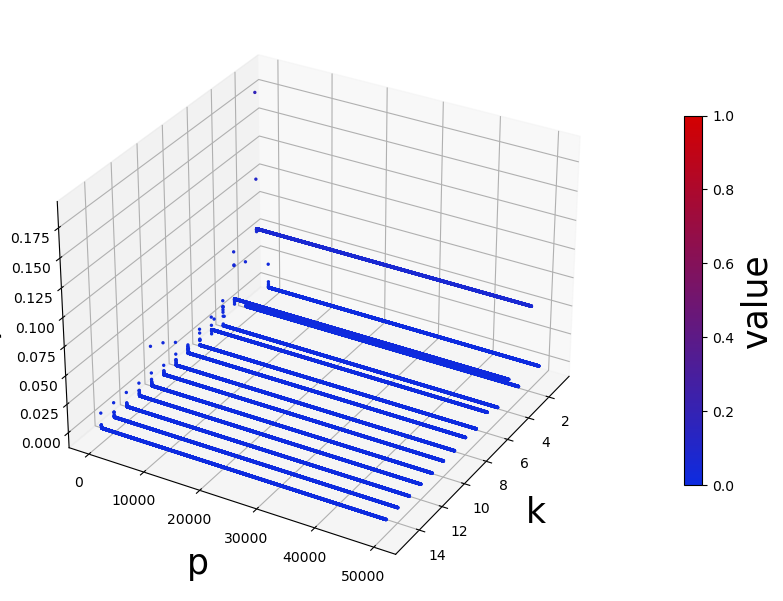

In [31]:
plot_max_bound(submaximal_index_p2_l_eq_2_filename, save="submaximal_index_p2-max_error_l-2.pdf")

plotted 76950 points, max eps = 0.3535


<Axes3DSubplot: xlabel='k', ylabel='p', zlabel='value'>

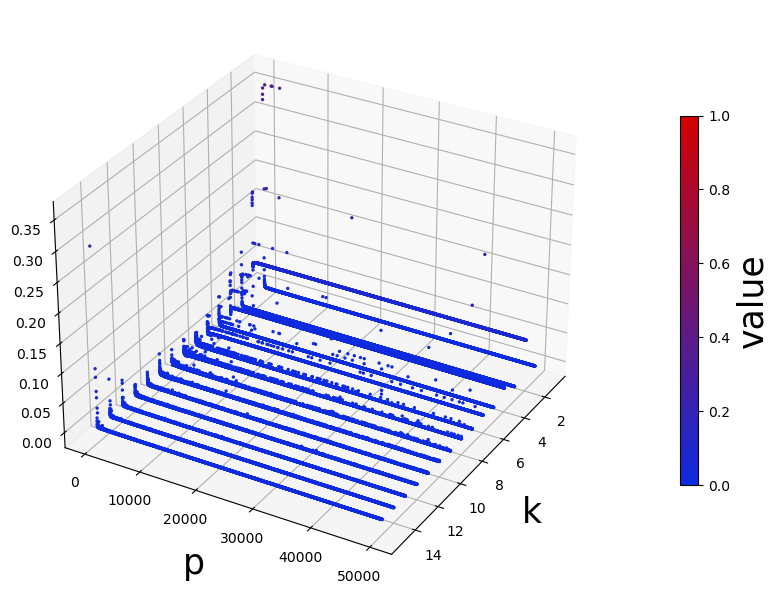

In [32]:
plot_max_bound(submaximal_index_q2_l_eq_2_filename, save="submaximal_index_q2-max_error_l-2.pdf")